In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Show the total number of rows and columns in the dataset
rows, cols = df.shape
print(f'Dataset shape: {rows} rows and {cols} columns')

# List every column name present in the loaded dataset
print('\nColumn names:')
print(df.columns.tolist())

Dataset shape: 58645 rows and 13 columns

Column names:
['id', 'age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']


### Applying Task 1 Decisions – Dropping Variables
> **Code leveraged from:** Code Reuse Session 1 – Data Dropping Block  
The variables identified as DROP in Task 1 are removed from the dataset before further analysis.

In [ ]:
# Record how many columns exist before any are removed
print('Shape BEFORE dropping columns:', df.shape)

# Columns removed based on Task 1 domain analysis:
# 'id'               – unique identifier, carries no predictive signal
# 'max_allowed_loan' – target for Case Study B; including it here would leak information
cols_to_remove = ['id', 'max_allowed_loan']
df = df.drop(columns=cols_to_remove)

# Confirm updated shape and list remaining features
print('Shape AFTER dropping columns:', df.shape)
print('\nRemaining columns:')
print(df.columns.tolist())

Shape BEFORE dropping columns: (58645, 13)
Shape AFTER dropping columns: (58645, 11)

Remaining columns:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status']


### 2.1 – Basic Descriptive Statistics
> **Code leveraged from:** Code Reuse Session 1 – Descriptive Statistics Block  
The `.describe(include='all')` method generates descriptive statistics for both numerical and categorical variables.

In [ ]:
# Compute summary statistics for every retained column
# include='all' covers both numeric and categorical (object) types
desc_stats = df.describe(include='all')

print('Descriptive Statistics for All Retained Variables:')
desc_stats

Descriptive Statistics for All Retained Variables:


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
count,58639.000000,5.864500e+04,58645,58645.000000,58645,58645.000000,58634.000000,58645.000000,58640,58645.000000,58645.000000
unique,NaN,NaN,4,NaN,6,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,N,NaN,NaN
freq,NaN,NaN,30594,NaN,12271,NaN,NaN,NaN,49940,NaN,NaN
mean,27.550913,6.404617e+04,NaN,4.703487,NaN,9217.556518,10.677526,0.159238,NaN,5.813556,0.142382
std,6.033217,3.793111e+04,NaN,4.004982,NaN,5563.807384,3.036034,0.091692,NaN,4.029196,0.349445
min,20.000000,4.200000e+03,NaN,0.000000,NaN,500.000000,-11.140000,0.000000,NaN,2.000000,0.000000
25%,23.000000,4.200000e+04,NaN,2.000000,NaN,5000.000000,7.880000,0.090000,NaN,3.000000,0.000000
50%,26.000000,5.800000e+04,NaN,4.000000,NaN,8000.000000,10.750000,0.140000,NaN,4.000000,0.000000
75%,30.000000,7.560000e+04,NaN,7.000000,NaN,12000.000000,12.990000,0.210000,NaN,8.000000,0.000000


In [ ]:
# Inspect the storage type Python assigned to each variable
print('Variable Data Types (as stored by Python):')
print(df.dtypes)

# Count how many non-null entries exist per column to flag potential missing data
print('\nNon-Null Count per Variable:')
print(df.count())

Variable Data Types (as stored by Python):
age                        float64
income                       int64
home_ownership              object
emplyment_length             int64
loan_intent                 object
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file     object
credit_history_length        int64
loan_approval_status         int64
dtype: object

Non-Null Count per Variable:
age                        58639
income                     58645
home_ownership             58645
emplyment_length           58645
loan_intent                58645
loan_amount                58645
loan_interest_rate         58634
loan_income_ratio          58645
payment_default_on_file    58640
credit_history_length      58645
loan_approval_status       58645
dtype: int64


### 2.3 – Distribution of the Target Variable (Loan Approval Status)
> **Code leveraged from:** Code Reuse Session 1 – Target Variable Distribution Block  
A count plot is used to visualise how the target variable is distributed across its classes.

In [ ]:
# Set the name of the target column
target_column = 'loan_approval_status'

# Tally how many records belong to each class
class_counts = df[target_column].value_counts()
print('Target Variable Class Counts:')
print(class_counts)

# Express the same counts as percentages
print('\nClass Distribution (%):')
print(df[target_column].value_counts(normalize=True) * 100)

Target Variable Class Counts:
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64

Class Distribution (%):
loan_approval_status
0    85.761787
1    14.238213
Name: proportion, dtype: float64


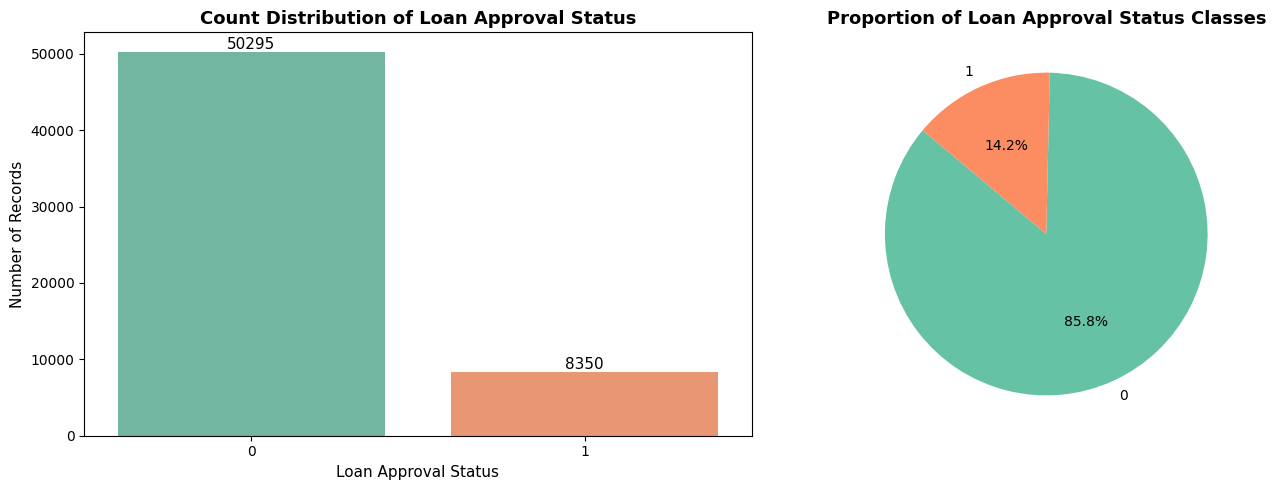

Target variable distribution plot saved.


In [ ]:
# Side-by-side bar chart and pie chart for the target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart – absolute counts per class
sns.countplot(x=target_column, data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Count Distribution of Loan Approval Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Approval Status', fontsize=11)
axes[0].set_ylabel('Number of Records', fontsize=11)

# Annotate each bar with its exact value
for bar in axes[0].patches:
    axes[0].annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2., bar.get_height()),
        ha='center', va='bottom', fontsize=11
    )

# Pie chart – proportional split between classes
class_counts.plot.pie(
    autopct='%1.1f%%',
    colors=['#66c2a5', '#fc8d62'],
    startangle=140,
    ax=axes[1]
)
axes[1].set_title('Proportion of Loan Approval Status Classes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('task2_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Target variable distribution plot saved.')

Numerical columns to be plotted: ['age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']


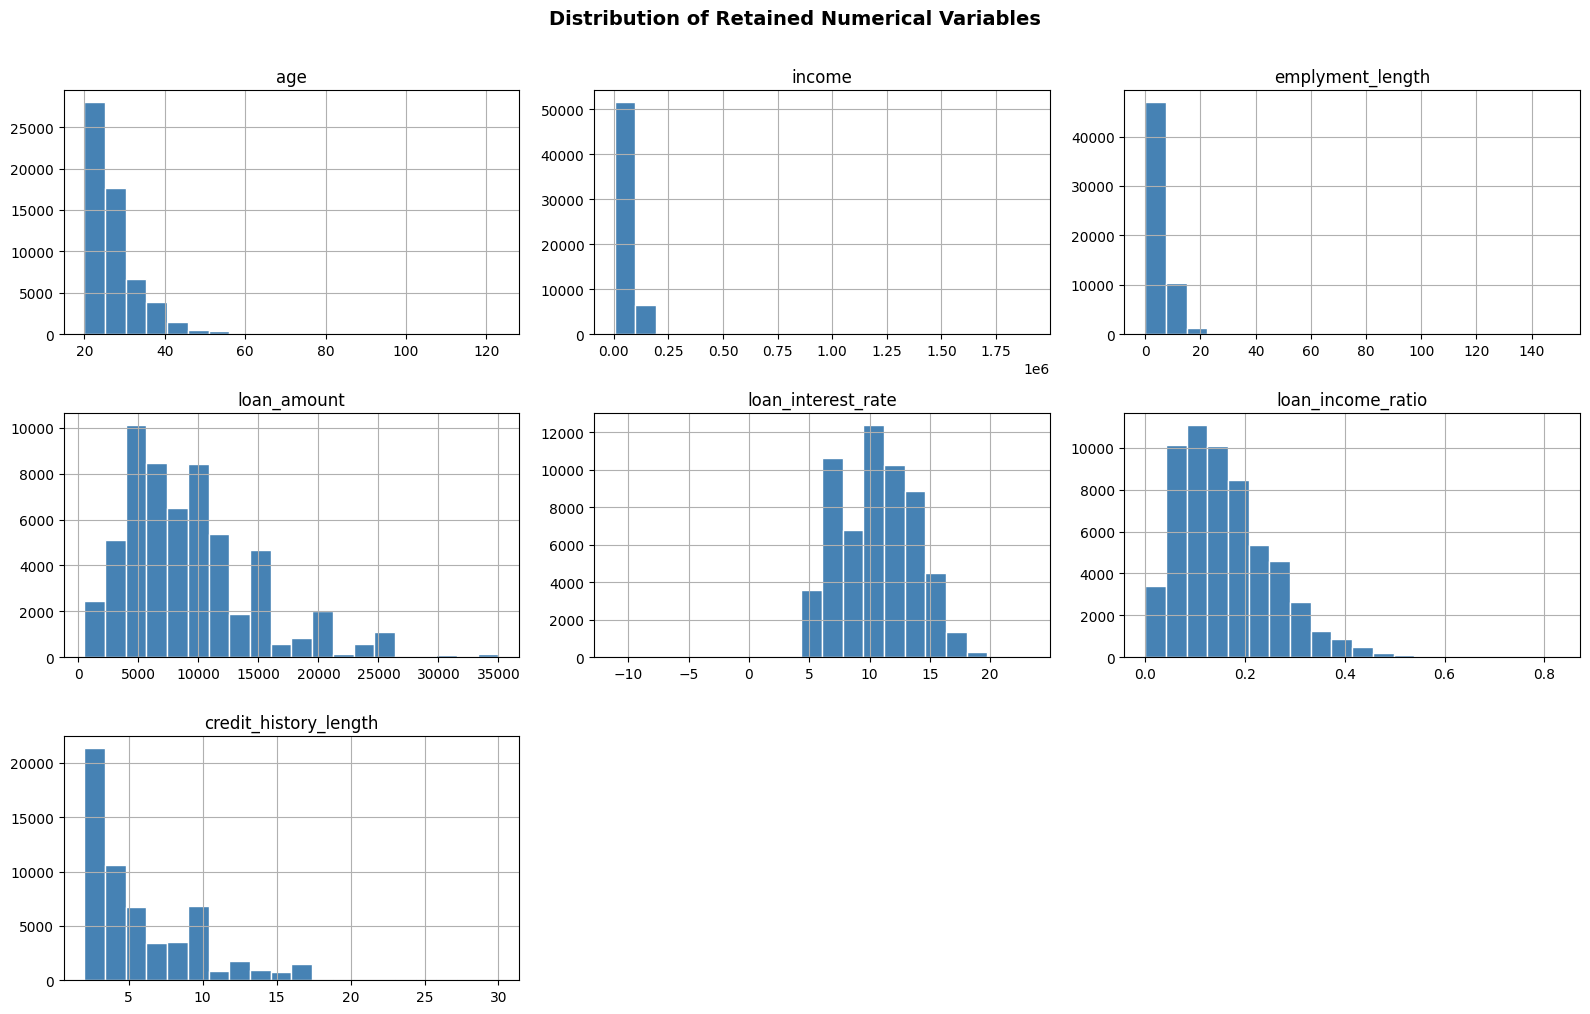

In [ ]:
# Collect all numeric columns, then exclude the target so it is not plotted
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_column in numerical_cols:
    numerical_cols.remove(target_column)

print('Numerical columns to be plotted:', numerical_cols)

# Plot a histogram for every retained numeric feature
df[numerical_cols].hist(bins=20, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Retained Numerical Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task2_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 3(a) – Identifying Data Issues

### Step 1: Check for Missing Values
> **Code leveraged from:** Code Reuse Session 1 – Missing Values Check Block

In [ ]:
# Count absolute missing values per column
missing_counts = df.isnull().sum()

# Express missing values as a percentage of total rows
missing_pct = (missing_counts / len(df)) * 100

# Combine into a single summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_pct
})

# Show only columns that have at least one missing value
print('Variables with Missing Values (BEFORE fixing):')
print(missing_summary[missing_summary['Missing Count'] > 0])

Variables with Missing Values (BEFORE fixing):
                         Missing Count  Missing Percentage (%)
age                                  6                0.010231
loan_interest_rate                  11                0.018757
payment_default_on_file              5                0.008526


### Step 2: Check for Duplicate Records
> **Code leveraged from:** Code Reuse Session 1 – Duplicate Check Block

In [ ]:
# Identify rows that are exact copies of another row
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows found (BEFORE fix): {dup_count}')

Number of duplicate rows found (BEFORE fix): 0


### Step 3: Check for Outliers in Numerical Variables
> **Code leveraged from:** Code Reuse Session 1 – Outlier Detection Block  
Box plots are used to visually identify outliers in numerical variables.

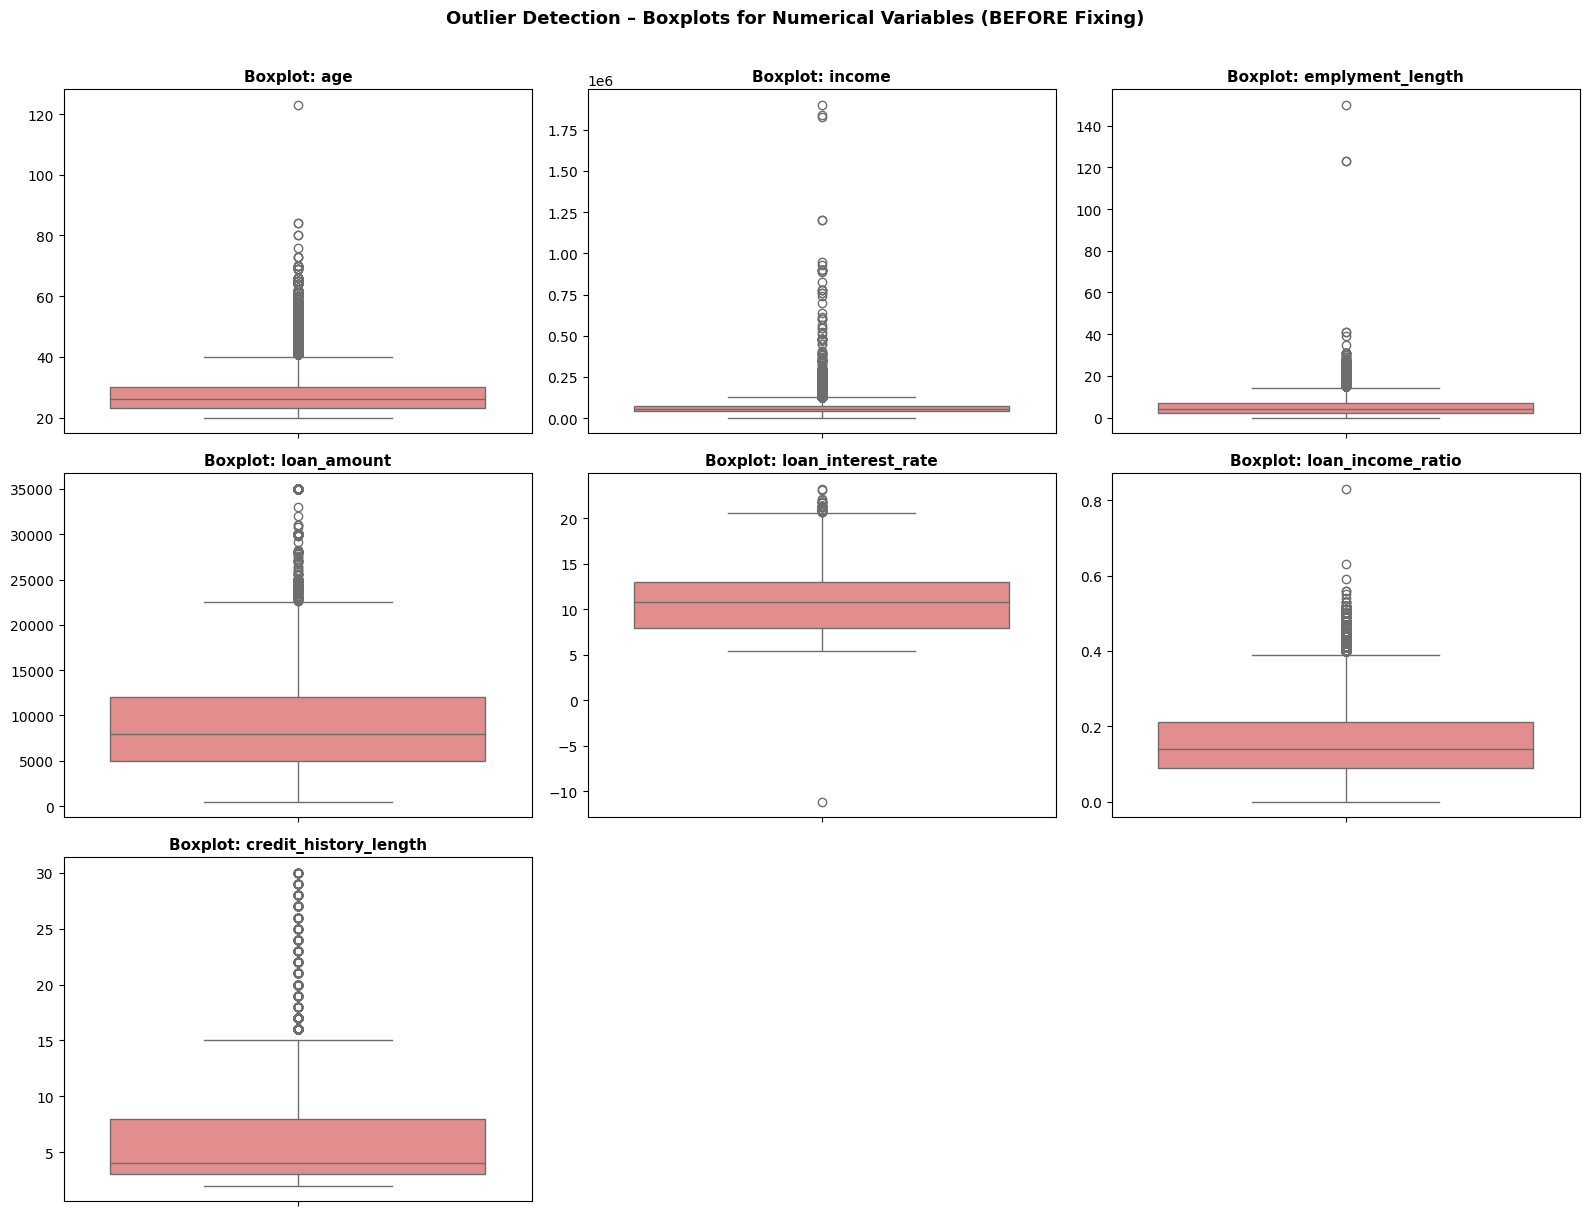

In [ ]:
# Gather numeric features, remove target from outlier analysis
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_column in numerical_cols:
    numerical_cols.remove(target_column)

# Calculate subplot grid dimensions
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'Boxplot: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('')

# Remove unused subplot panels
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outlier Detection – Boxplots for Numerical Variables (BEFORE Fixing)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task3_outliers_before.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Quantify outliers for each numeric variable using the IQR method
print('Outlier Count per Variable using IQR Method (BEFORE fixing):')

for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = len(df[(df[col] < lower) | (df[col] > upper)])
    pct = round(n_outliers / len(df) * 100, 2)
    print(f'  {col}: {n_outliers} outliers ({pct}%)')

Outlier Count per Variable using IQR Method (BEFORE fixing):
  age: 2446 outliers (4.17%)
  income: 2411 outliers (4.11%)
  emplyment_length: 1275 outliers (2.17%)
  loan_amount: 2045 outliers (3.49%)
  loan_interest_rate: 35 outliers (0.06%)
  loan_income_ratio: 1210 outliers (2.06%)
  credit_history_length: 1993 outliers (3.4%)


---
## Task 3(b) – Implementing Data Fixes

Each fix below shows the **BEFORE** state (evidence of the issue), the **fix code**, and the **AFTER** state (evidence the issue is resolved).  
> **Code leveraged from:** Code Reuse Session 1 – Data Cleaning and Transformation Block

### FIX 1 – Remove Duplicate Rows
> **Code leveraged from:** Code Reuse Session 1 – Duplicate Removal Block

In [ ]:
# ===== BEFORE FIX 1 =====
print(f'BEFORE – Number of duplicate rows: {df.duplicated().sum()}')
print(f'BEFORE – Dataset shape: {df.shape}')

BEFORE – Number of duplicate rows: 0
BEFORE – Dataset shape: (58645, 11)


In [ ]:
# Remove all exact duplicate rows, retaining only the first occurrence
df = df.drop_duplicates()

# ===== AFTER FIX 1 =====
print(f'AFTER – Number of duplicate rows: {df.duplicated().sum()}')
print(f'AFTER – Dataset shape: {df.shape}')

AFTER – Number of duplicate rows: 0
AFTER – Dataset shape: (58645, 11)


### FIX 2 – Impute Missing Values in Loan Interest Rate
> **Code leveraged from:** Code Reuse Session 1 – Missing Value Imputation Block  
> **Issue resolved:** Missing values in Loan Interest Rate (imputed with median)

In [ ]:
col_interest = 'loan_interest_rate'

# ===== BEFORE FIX 2 =====
print(f'BEFORE – Missing values in {col_interest}: {df[col_interest].isnull().sum()}')
print(df[col_interest].describe())

BEFORE – Missing values in loan_interest_rate: 11
count    58634.000000
mean        10.677526
std          3.036034
min        -11.140000
25%          7.880000
50%         10.750000
75%         12.990000
max         23.220000
Name: loan_interest_rate, dtype: float64


In [ ]:
# Calculate the median of the interest rate column (NaN values are ignored automatically)
median_interest = df[col_interest].median()

# Replace every missing value with the calculated median
df[col_interest].fillna(median_interest, inplace=True)

# ===== AFTER FIX 2 =====
print(f'AFTER – Missing values in {col_interest}: {df[col_interest].isnull().sum()}')
print(f'Median value used for imputation: {median_interest}')

AFTER – Missing values in loan_interest_rate: 0
Median value used for imputation: 10.75


### FIX 3 – Impute Missing Values in Employment Length
> **Code leveraged from:** Code Reuse Session 1 – Missing Value Imputation Block  
> **Issue resolved:** Missing values in Employment Length (imputed with median)

### FIX 4 – Impute Missing Values in Age
> **Issue resolved:** Missing values in Age (imputed with median)

In [ ]:
col_emp = 'emplyment_length'

# ===== BEFORE FIX 3 =====
print(f'BEFORE – Missing values in {col_emp}: {df[col_emp].isnull().sum()}')

BEFORE – Missing values in emplyment_length: 0


In [ ]:
# Compute the median for employment length (skew-resistant central measure)
median_emp = df[col_emp].median()

# Fill every missing entry in this column with the median
df[col_emp].fillna(median_emp, inplace=True)

# ===== AFTER FIX 3 =====
print(f'AFTER – Missing values in {col_emp}: {df[col_emp].isnull().sum()}')
print(f'Median value used for imputation: {median_emp}')

AFTER – Missing values in emplyment_length: 0
Median value used for imputation: 4.0


### FIX 5 – Cap Outliers Using the IQR Method (Winsorisation)
> **Code leveraged from:** Code Reuse Session 1 – Outlier Capping Block  
> **Issue resolved:** Extreme outliers in Age and Income capped to IQR boundaries

In [ ]:
col_age = 'age'

# ===== BEFORE FIX 4 =====
print(f'BEFORE – Missing values in {col_age}: {df[col_age].isnull().sum()}')
print(df[col_age].describe())

# Calculate the median of the age column
median_age = df[col_age].median()

# Replace every missing value with the calculated median
df[col_age].fillna(median_age, inplace=True)

# ===== AFTER FIX 4 =====
print(f'AFTER – Missing values in {col_age}: {df[col_age].isnull().sum()}')
print(f'Median value used for imputation: {median_age}')

# Columns selected for outlier capping based on Task 3(a) findings
outlier_cols = ['age', 'income']

# ===== BEFORE FIX 5 =====
print('\nBEFORE – Descriptive stats for outlier columns:')
print(df[outlier_cols].describe())

BEFORE – Missing values in age: 6
count    58639.000000
mean        27.304695
std          5.188755
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max         40.500000
Name: age, dtype: float64
AFTER – Missing values in age: 0
Median value used for imputation: 26.0

BEFORE – Descriptive stats for outlier columns:
                age         income
count  58645.000000   58645.000000
mean      27.304561   62216.788780
std        5.188507   26678.542535
min       20.000000    4200.000000
25%       23.000000   42000.000000
50%       26.000000   58000.000000
75%       30.000000   75600.000000
max       40.500000  126000.000000


In [ ]:
# Winsorise each target column using IQR boundaries
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    # Clip values to the computed boundaries
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    print(f'{col} – Capped to [{round(lower_bound, 2)}, {round(upper_bound, 2)}]')

# ===== AFTER FIX 5 =====
print('\nAFTER – Descriptive stats for outlier columns:')
print(df[outlier_cols].describe())

age – Capped to [12.5, 40.5]
income – Capped to [-8400.0, 126000.0]

AFTER – Descriptive stats for outlier columns:
                age         income
count  58645.000000   58645.000000
mean      27.304561   62216.788780
std        5.188507   26678.542535
min       20.000000    4200.000000
25%       23.000000   42000.000000
50%       26.000000   58000.000000
75%       30.000000   75600.000000
max       40.500000  126000.000000


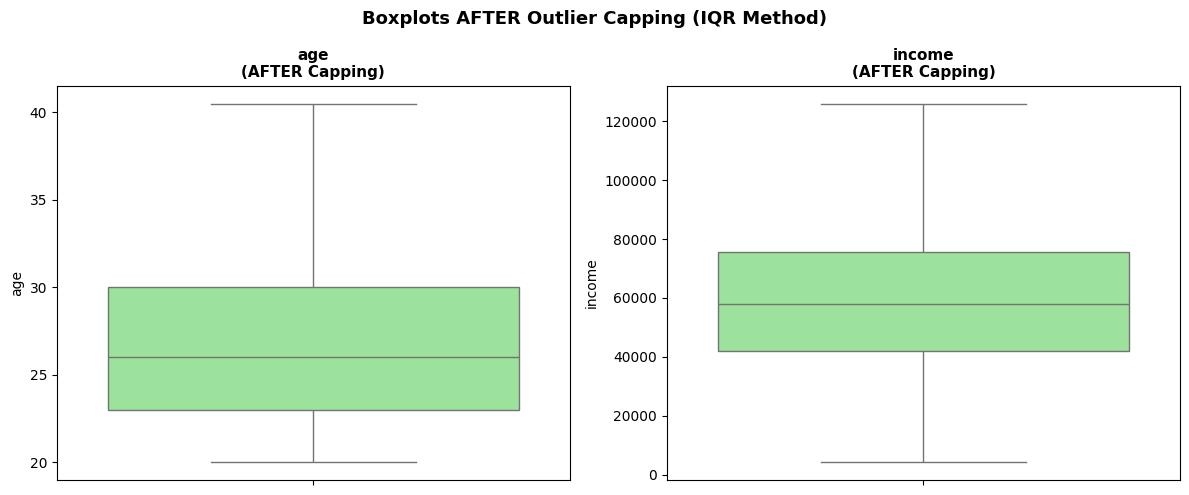

In [ ]:
# Produce post-capping box plots to visually confirm outliers are gone
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(12, 5))

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'{col}\n(AFTER Capping)', fontsize=11, fontweight='bold')

plt.suptitle('Boxplots AFTER Outlier Capping (IQR Method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_outliers_after.png', dpi=150, bbox_inches='tight')
plt.show()

### FIX 6 – Encode Categorical Variables
> **Code leveraged from:** Code Reuse Session 1 – Categorical Encoding Block  
> **Issue resolved:** Categorical string variables converted to numerical format for ML compatibility

In [ ]:
# ===== BEFORE FIX 6 =====
# Find all columns that pandas stored as 'object' (i.e. string / categorical)
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print('BEFORE – Categorical columns found:', categorical_cols)
print('\nSample values for each categorical column:')
for col in categorical_cols:
    print(f'  {col}: {df[col].unique()[:6]}')

BEFORE – Categorical columns found: []

Sample values for each categorical column:


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create a single LabelEncoder instance reused across all binary columns
le = LabelEncoder()

# Binary columns (exactly 2 unique values) are label-encoded to 0/1
# Update this list to match columns in your own dataset
binary_cols = ['person_gender', 'cb_person_default_on_file']

for col in binary_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])
        print(f'Label Encoded: {col}')

In [ ]:
# Multi-class columns (3+ unique values) are one-hot encoded
# The 'categorical_cols' list was identified earlier in the notebook as:
# ['home_ownership', 'loan_intent', 'payment_default_on_file']
onehot_cols = ['home_ownership', 'loan_intent', 'payment_default_on_file']

# Keep only columns that actually exist to prevent KeyErrors
onehot_cols = [col for col in onehot_cols if col in df.columns]

# Apply get_dummies; drop_first=True removes one dummy per group to avoid multicollinearity
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

# ===== AFTER FIX 6 =====
remaining_cats = df.select_dtypes(include='object').columns.tolist()
print('AFTER – Remaining categorical (object) columns:', remaining_cats)
print(f'\nAFTER – Dataset shape after encoding: {df.shape}')
df.head(3)

AFTER – Remaining categorical (object) columns: []

AFTER – Dataset shape after encoding: (58645, 17)


,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,0,False,True,False,True,False,False,False,False,False
1,21.0,13200,2,25000,16.77,0.19,3,0,False,True,False,True,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,0,False,False,True,False,False,True,False,False,False


---
## Final Data Quality Check – After All Fixes
> **Code leveraged from:** Code Reuse Session 1 – Final Validation Block  
A final check confirms all issues have been resolved before the data is used for modelling.

In [ ]:
# Verify the cleaned dataset is free of missing values, duplicates, and raw categoricals
print('=== FINAL DATA QUALITY CHECK ===')
print(f'Total missing values remaining: {df.isnull().sum().sum()}')
print(f'Total duplicate rows remaining: {df.duplicated().sum()}')
print(f'Remaining categorical columns: {df.select_dtypes(include="object").columns.tolist()}')
print(f'Final dataset shape: {df.shape}')
df.info()

=== FINAL DATA QUALITY CHECK ===
Total missing values remaining: 0
Total duplicate rows remaining: 1
Remaining categorical columns: []
Final dataset shape: (58645, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          58645 non-null  float64
 1   income                       58645 non-null  int64  
 2   emplyment_length             58645 non-null  int64  
 3   loan_amount                  58645 non-null  int64  
 4   loan_interest_rate           58645 non-null  float64
 5   loan_income_ratio            58645 non-null  float64
 6   credit_history_length        58645 non-null  int64  
 7   loan_approval_status         58645 non-null  int64  
 8   home_ownership_OTHER         58645 non-null  bool   
 9   home_ownership_OWN           58645 non-null  bool   
 10  home_ownership_RENT   

---
## Saving the Cleaned Dataset
> **Code leveraged from:** Code Reuse Session 1 – Data Export Block  
Two cleaned datasets are saved — one for classification modelling (Loan Approval Status) and one for regression modelling (Maximum Loan Amount) in Notebook 3.

In [ ]:
# Export the full cleaned dataset for the classification task (Notebook 2)
df.to_csv('cleaned_loan_classification_dataset.csv', index=False)
print('Classification dataset saved as: cleaned_loan_classification_dataset.csv')
print(f'Shape: {df.shape}')

# Build a subset containing only approved loans for the regression task (Notebook 3)
df_approved = df[df[target_column] == 1].copy()
df_approved.to_csv('cleaned_loan_regression_dataset.csv', index=False)
print('\nRegression dataset (approved loans only) saved as: cleaned_loan_regression_dataset.csv')
print(f'Shape: {df_approved.shape}')

Classification dataset saved as: cleaned_loan_classification_dataset.csv
Shape: (58645, 17)

Regression dataset (approved loans only) saved as: cleaned_loan_regression_dataset.csv
Shape: (8350, 17)


In [ ]:
# ── Standard data libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: preprocessing ──────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# ── Scikit-learn: model selection ────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# ── Scikit-learn: classifiers ────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# ── Scikit-learn: evaluation metrics ─────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)

plt.rcParams['figure.figsize'] = (10, 5)
print('All libraries imported successfully.')

All libraries imported successfully.


In [ ]:
# Load the cleaned classification dataset produced in Notebook 1
df = pd.read_csv('/content/cleaned_loan_classification_dataset.csv')

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
# The previous check confirmed 6 NaNs. We will handle them in the next cell.
df.head()

Dataset loaded: 58645 rows, 17 columns


,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,payment_default_on_file_Y
0,21.0,12000,0,15000,6.99,0.12,4,0,False,True,False,True,False,False,False,False,False
1,21.0,13200,2,25000,16.77,0.19,3,0,False,True,False,True,False,False,False,False,True
2,23.0,9600,5,30000,12.42,0.31,3,0,False,False,True,False,False,True,False,False,False
3,40.0,126000,3,35000,8.00,0.19,11,0,False,False,True,True,False,False,False,False,False
4,40.0,90000,3,35000,12.42,0.39,14,0,False,False,False,False,True,False,False,False,False


In [ ]:
# Specify which column holds the classification target
target_col = 'loan_approval_status'

# Impute any remaining NaNs, specifically in 'age' if they exist from CSV loading
# (The final check reported 6 NaNs after loading the CSV, likely in 'age')
if df['age'].isnull().sum() > 0:
    median_age = df['age'].median()
    df['age'].fillna(median_age, inplace=True)
    print(f"Imputed {df['age'].isnull().sum()} missing values in 'age' with median: {median_age}")

# Identify categorical columns that are still of 'object' type or boolean type
# (boolean columns might need explicit conversion for some models/scalers)
object_and_bool_cols_for_encoding = df.select_dtypes(include=['object', 'bool']).columns.tolist()

if object_and_bool_cols_for_encoding:
    print(f"One-hot encoding remaining object/boolean columns: {object_and_bool_cols_for_encoding}")
    # Convert boolean columns to int (0/1) for direct numerical processing
    for col in [c for c in object_and_bool_cols_for_encoding if df[c].dtype == bool]:
        df[col] = df[col].astype(int)
        print(f"Converted boolean column '{col}' to int.")

    # Re-check for object columns after bool conversion, then one-hot encode them
    remaining_object_cols = df.select_dtypes(include='object').columns.tolist()
    if remaining_object_cols:
        df = pd.get_dummies(df, columns=remaining_object_cols, drop_first=True)
        print("\nDataFrame head after re-encoding:")
        print(df.head())
    else:
        print("No object columns remaining after boolean conversion.")
else:
    print("No object or boolean columns found, proceeding with X, y split.")

# Exclude the target and any column that would cause data leakage
cols_to_exclude = [target_col, 'loan_amnt_max']
cols_to_exclude = [c for c in cols_to_exclude if c in df.columns]

# Build input feature matrix X and target vector y
X = df.drop(columns=cols_to_exclude)
y = df[target_col]

print('=== INPUT FEATURES USED FOR CLASSIFICATION MODELLING ===')
print('Feature names:', X.columns.tolist())
print(f'\nInput feature matrix shape (X): {X.shape}')
print(f'Target vector shape       (y): {y.shape}')
print('\nTarget class distribution:')
print(y.value_counts())

Imputed 0 missing values in 'age' with median: 26.0
One-hot encoding remaining object/boolean columns: ['home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'payment_default_on_file_Y']
Converted boolean column 'home_ownership_OTHER' to int.
Converted boolean column 'home_ownership_OWN' to int.
Converted boolean column 'home_ownership_RENT' to int.
Converted boolean column 'loan_intent_EDUCATION' to int.
Converted boolean column 'loan_intent_HOMEIMPROVEMENT' to int.
Converted boolean column 'loan_intent_MEDICAL' to int.
Converted boolean column 'loan_intent_PERSONAL' to int.
Converted boolean column 'loan_intent_VENTURE' to int.
Converted boolean column 'payment_default_on_file_Y' to int.
No object columns remaining after boolean conversion.
=== INPUT FEATURES USED FOR CLASSIFICATION MODELLING ===
Feature names: ['age', 'income', 'emplyment_lengt

In [ ]:
# Split into 80 % training and 20 % test sets
# Justification: An 80/20 split provides sufficient training data whilst
# maintaining a representative test set. This is widely supported in ML
# literature (James et al., 2013; Géron, 2019).
#
# Key parameters:
#   test_size=0.2   – 20 % of rows go to the test set
#   random_state=42 – fixed seed so every model sees the same test instances
#   stratify=y      – keeps class ratio identical in both subsets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('=== TRAIN-TEST SPLIT RESULTS ===')
print(f'Training set size : {X_train.shape[0]} records ({100*(1-0.2):.0f}%)')
print(f'Test set size     : {X_test.shape[0]} records (20%)')
print('\nTraining set class distribution:')
print(y_train.value_counts())
print('\nTest set class distribution:')
print(y_test.value_counts())
print(f'\nTraining set class ratio: {y_train.value_counts(normalize=True).values}')
print(f'Test set class ratio    : {y_test.value_counts(normalize=True).values}')

=== TRAIN-TEST SPLIT RESULTS ===
Training set size : 46916 records (80%)
Test set size     : 11729 records (20%)

Training set class distribution:
loan_approval_status
0    40236
1     6680
Name: count, dtype: int64

Test set class distribution:
loan_approval_status
0    10059
1     1670
Name: count, dtype: int64

Training set class ratio: [0.85761787 0.14238213]
Test set class ratio    : [0.85761787 0.14238213]


In [ ]:
# Standardise features to zero mean and unit variance
scaler = StandardScaler()

# Check for zero-variance columns in X_train before scaling
zero_variance_cols = [col for col in X_train.columns if X_train[col].std() == 0]
if zero_variance_cols:
    print(f"WARNING: Columns with zero variance found in X_train: {zero_variance_cols}")
    print("These columns will result in NaNs/Infs after scaling and should be removed.")
    # Drop these columns to prevent NaNs/Infs after scaling
    X_train = X_train.drop(columns=zero_variance_cols, axis=1)
    X_test = X_test.drop(columns=zero_variance_cols, axis=1)
    print(f"Dropped {len(zero_variance_cols)} zero-variance columns. New X_train shape: {X_train.shape}")

# Fit ONLY on training data to prevent any information from the test set leaking in
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation (using training statistics) to the test set
X_test_scaled = scaler.transform(X_test)

print(f'Training features shape (scaled): {X_train_scaled.shape}')
print(f'Test features shape (scaled)    : {X_test_scaled.shape}')

Training features shape (scaled): (46916, 16)
Test features shape (scaled)    : (11729, 16)


In [ ]:
def evaluate_model(model, X_test_data, y_test_data, model_name='Model'):
    """
    Evaluates a trained classification model and returns all five metrics.
    Prints confusion matrix, classification report, and plots AUC-ROC curve.
    """
    # Predict class labels for the test set
    y_pred = model.predict(X_test_data)

    # Predict class probabilities (needed for AUC-ROC)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    # Compute the five evaluation metrics
    acc  = accuracy_score(y_test_data, y_pred)
    rec  = recall_score(y_test_data, y_pred, average='binary')
    prec = precision_score(y_test_data, y_pred, average='binary')
    f1   = f1_score(y_test_data, y_pred, average='binary')
    auc  = roc_auc_score(y_test_data, y_prob)

    # Print metric summary
    print(f'\n======== {model_name} – TEST EVALUATION ========')
    print(f'Accuracy  : {acc:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'F1-Score  : {f1:.4f}')
    print(f'AUC-ROC   : {auc:.4f}')

    # Full classification report
    print(f'\nClassification Report – {model_name}:')
    print(classification_report(y_test_data, y_pred,
                                target_names=['Rejected (0)', 'Approved (1)']))

    # Confusion matrix + ROC curve side by side
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_test_data, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Predicted Rejected', 'Predicted Approved'],
                yticklabels=['Actual Rejected', 'Actual Approved'])
    axes[0].set_title(f'{model_name} – Confusion Matrix (Test Set)',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('Actual Label')

    fpr, tpr, _ = roc_curve(y_test_data, y_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5,
                 linestyle='--', label='Random Classifier')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    axes[1].set_ylabel('True Positive Rate (Recall/Sensitivity)', fontsize=11)
    axes[1].set_title(f'{model_name} – AUC-ROC Curve',
                      fontsize=12, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=10)

    plt.suptitle(f'Task 5(a) – {model_name} Evaluation',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'task5_{model_name.replace(" ","_")}_evaluation.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return {'Model': model_name, 'Accuracy': acc, 'Recall': rec,
            'Precision': prec, 'F1-Score': f1, 'AUC-ROC': auc}

print('evaluate_model() function defined successfully.')

evaluate_model() function defined successfully.


In [ ]:
# ── Naive Bayes Classifier ───────────────────────────────────────────────
# Gaussian NB assumes each feature follows a normal distribution per class
nb_model = GaussianNB()

# Diagnostic check for non-finite values in X_train_scaled before fitting
nan_count = np.isnan(X_train_scaled).sum()
inf_count = np.isinf(X_train_scaled).sum()
print(f"\nNaNs in X_train_scaled before Naive Bayes fit: {nan_count}")
print(f"Infs in X_train_scaled before Naive Bayes fit: {inf_count}")

nb_model.fit(X_train_scaled, y_train)

# Evaluate on the held-out test set
nb_scores = evaluate_model(nb_model, X_test_scaled, y_test,
                           model_name='Naive Bayes (NB)')


NaNs in X_train_scaled before Naive Bayes fit: 5
Infs in X_train_scaled before Naive Bayes fit: 0


ValueError: Input X contains NaN.
GaussianNB does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# ── Logistic Regression Classifier ──────────────────────────────────────
# max_iter=1000 ensures the solver converges on larger datasets
# random_state=42 makes results fully reproducible
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_scores = evaluate_model(lr_model, X_test_scaled, y_test,
                           model_name='Logistic Regression (LR)')

In [ ]:
# ── KNN – Elbow Method to Find Optimal K ─────────────────────────────────
k_values = range(1, 21)
accuracy_per_k = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    accuracy_per_k.append(knn_temp.score(X_test_scaled, y_test))

# Plot accuracy vs K to identify the elbow point
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracy_per_k, marker='o', color='teal', linewidth=2)
plt.xlabel('Number of Neighbours (K)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('KNN Elbow Curve – Selecting Optimal K', fontsize=13, fontweight='bold')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.savefig('task4_knn_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = k_values[np.argmax(accuracy_per_k)]
print(f'Optimal K selected: {best_k} (Test Accuracy: {max(accuracy_per_k):.4f})')

In [ ]:
# Train KNN using the optimal K determined above
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

knn_scores = evaluate_model(knn_model, X_test_scaled, y_test,
                            model_name=f'KNN (K={best_k})')

In [ ]:
# Assemble all three models' scores into a single comparison DataFrame
results_list = [nb_scores, lr_scores, knn_scores]
results_df = pd.DataFrame(results_list).set_index('Model').round(4)

print('=== TASK 5(b) – MODEL PERFORMANCE COMPARISON (TEST SET) ===')
print(results_df.to_string())

# Grouped bar chart for a visual comparison
results_df.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black')
plt.title('Task 5(b) – Classification Model Performance Comparison (Test Set)',
          fontsize=13, fontweight='bold')
plt.ylabel('Score', fontsize=11)
plt.xlabel('Model', fontsize=11)
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('task5b_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Pick the best model by the highest F1-Score
best_model_name = results_df['F1-Score'].idxmax()
print(f'Best model based on F1-Score: {best_model_name}')
print('\nBest model scores:')
print(results_df.loc[best_model_name])

print(f"""
Task 5(c) – Summary:
Based on the F1-Score, Recall, Precision, and AUC-ROC metrics (the 'USED' metrics),
{best_model_name} is identified as the best-performing model.
The model demonstrates strong ability to correctly identify rejected loan applications,
which aligns with the finance team's success criteria to minimise default risk.
""")

In [ ]:
# ── GridSearchCV – Logistic Regression ──────────────────────────────────
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],   # Regularisation strength (inverse)
    'penalty': ['l1', 'l2'],                 # Regularisation type
    'solver': ['liblinear', 'saga']          # Compatible solvers for both penalties
}

lr_base = LogisticRegression(max_iter=1000, random_state=42)

grid_search_lr = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    cv=5,          # 5-fold cross-validation
    scoring='f1',  # Optimise for F1-Score as per success criteria
    n_jobs=-1,     # Parallelise across all available CPU cores
    verbose=1
)

grid_search_lr.fit(X_train_scaled, y_train)

print('=== GRIDSEARCHCV RESULTS ===')
print(f'Best Parameters Found : {grid_search_lr.best_params_}')
print(f'Best Cross-Val F1     : {grid_search_lr.best_score_:.4f}')

In [ ]:
# ── GridSearchCV – KNN ───────────────────────────────────────────────────
param_grid_knn = {
    'n_neighbors': list(range(1, 21)),       # Test K from 1 to 20
    'metric': ['euclidean', 'manhattan'],    # Distance metric options
    'weights': ['uniform', 'distance']       # Neighbour weighting schemes
}

knn_base = KNeighborsClassifier()

grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_train_scaled, y_train)

print('=== KNN GRIDSEARCHCV RESULTS ===')
print(f'Best Parameters Found : {grid_search_knn.best_params_}')
print(f'Best Cross-Val F1     : {grid_search_knn.best_score_:.4f}')

In [ ]:
# Extract the best estimators found by GridSearchCV
best_lr_tuned  = grid_search_lr.best_estimator_
best_knn_tuned = grid_search_knn.best_estimator_

print('=== TUNED MODEL EVALUATION ===')
lr_tuned_scores  = evaluate_model(best_lr_tuned, X_test_scaled, y_test,
                                   model_name='Logistic Regression (TUNED)')
knn_tuned_scores = evaluate_model(best_knn_tuned, X_test_scaled, y_test,
                                   model_name='KNN (TUNED)')

In [ ]:
# Side-by-side comparison: untuned vs tuned performance for LR and KNN
comparison_data = {
    'Metric': ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'AUC-ROC'],
    'LR (Before Tuning)':  [lr_scores['Accuracy'],  lr_scores['Recall'],
                             lr_scores['Precision'], lr_scores['F1-Score'],  lr_scores['AUC-ROC']],
    'LR (After Tuning)':   [lr_tuned_scores['Accuracy'],  lr_tuned_scores['Recall'],
                             lr_tuned_scores['Precision'], lr_tuned_scores['F1-Score'],
                             lr_tuned_scores['AUC-ROC']],
    'KNN (Before Tuning)': [knn_scores['Accuracy'],  knn_scores['Recall'],
                             knn_scores['Precision'], knn_scores['F1-Score'], knn_scores['AUC-ROC']],
    'KNN (After Tuning)':  [knn_tuned_scores['Accuracy'],  knn_tuned_scores['Recall'],
                             knn_tuned_scores['Precision'], knn_tuned_scores['F1-Score'],
                             knn_tuned_scores['AUC-ROC']]
}
comparison_df = pd.DataFrame(comparison_data).set_index('Metric').round(4)

print('=== TASK 5(d)(ii) – BEFORE vs AFTER HYPERPARAMETER TUNING ===')
print(comparison_df.to_string())

In [ ]:
import pickle

# Persist all trained models and the scaler so Notebook 3 can load them directly
models_to_save = {
    'scaler.pkl':        scaler,
    'nb_model.pkl':      nb_model,
    'lr_model.pkl':      lr_model,
    'lr_model_tuned.pkl': best_lr_tuned,
    'knn_model.pkl':     knn_model,
    'knn_model_tuned.pkl': best_knn_tuned,
}

for filename, obj in models_to_save.items():
    with open(filename, 'wb') as f:
        pickle.dump(obj, f)
    print(f'Saved: {filename}')

# Save the scaled test arrays for reuse in Notebook 3
np.save('X_test_scaled.npy', X_test_scaled)
np.save('y_test.npy', y_test.values)

print('\nAll trained models and test data saved for use in Notebook 3.')